In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/My Drive/single_cell_isoform_smoothing/

/content/drive/My Drive/single_cell_isoform_smoothing


In [3]:
!pip install scanpy
!pip install diptest
!pip install --upgrade networkx


import numpy as np
import pandas as pd
import sklearn
import scipy
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.notebook import tqdm
import networkx as nx
import torch
from scipy.sparse import csr_matrix



In [4]:
if torch.cuda.is_available():
  dev = "cuda:0"
else:
  dev = "cpu"
device = torch.device(dev)

if torch.cuda.is_available():
   print ("Cuda is available")
   device_id = torch.cuda.current_device()
   gpu_properties = torch.cuda.get_device_properties(device_id)
   print("Found %d GPUs available. Using GPU %d (%s) of compute capability %d.%d with "
          "%.1fGb total memory.\n" %
          (torch.cuda.device_count(),
          device_id,
          gpu_properties.name,
          gpu_properties.major,
          gpu_properties.minor,
          gpu_properties.total_memory / 1e9))
else:
   print ("Cuda is not available")

Cuda is available
Found 1 GPUs available. Using GPU 0 (NVIDIA L4) of compute capability 8.9 with 23.8Gb total memory.



In [5]:
def simrank_similarity_optimized(adj_matrix, decay_factor=0.8, max_iter=1000, eps=1e-4, device='cpu'):
    """
    Optimized SimRank similarity computation using matrix operations to avoid for loops.

    Parameters:
    adj_matrix (torch.Tensor): Adjacency matrix (n x n) where n is the number of nodes.
    decay_factor (float): Decay factor (C) in the SimRank equation, usually between 0 and 1.
    max_iter (int): Maximum number of iterations to run the algorithm.
    eps (float): Convergence threshold for stopping criterion.
    device (str): Device to run the computation ('cpu' or 'cuda').

    Returns:
    torch.Tensor: SimRank similarity matrix (n x n).
    """
    n = adj_matrix.shape[0]  # Number of nodes
    sim_matrix = torch.eye(n, device=device)  # Initialize similarity matrix as identity (self-similarity = 1)

    # Normalize the adjacency matrix by the out-degree (number of neighbors)
    out_degrees = adj_matrix.sum(dim=1, keepdim=True)
    norm_adj_matrix = torch.where(out_degrees > 0, adj_matrix / out_degrees, adj_matrix).to(device)

    # Iterate to update similarity scores
    for _ in range(max_iter):
        new_sim_matrix = sim_matrix.clone()  # Copy the similarity matrix for updating

        # Compute pairwise similarities using matrix operations
        sim_scores = torch.matmul(norm_adj_matrix, torch.matmul(sim_matrix, norm_adj_matrix.T))
        new_sim_matrix = decay_factor * sim_scores

        # Ensure self-similarity remains 1 (diagonal elements)
        new_sim_matrix.fill_diagonal_(1)

        # Check for convergence
        if torch.norm(new_sim_matrix - sim_matrix) < eps:
            break

        sim_matrix = new_sim_matrix

    return sim_matrix


def gaussian_kernel_weights_with_simrank(distances: csr_matrix, sim_matrix: np.ndarray, k: int, device='cpu') -> torch.Tensor:
    """
    Calculate Gaussian kernel-based weights for a kNN graph based on distances and SimRank similarity matrix.

    Parameters
    ----------
    distances: csr_matrix
        The input sparse matrix of distances between cells. Non-nearest neighbors are set to 0.

    sim_matrix: np.ndarray
        The SimRank similarity matrix (dense, NumPy array).

    k: int
        The number of nearest neighbors to consider for intersection.

    device: str
        Device for torch tensors ('cpu' or 'cuda').

    Returns
    -------
    weights: torch.Tensor
        A symmetric weight matrix with Gaussian kernel weights.
    """
    # Convert the sparse distance matrix to dense and move to the specified device
    distances_dense = distances.toarray()
    distances_tensor = torch.tensor(distances_dense, dtype=torch.float32).to(device)

    # Convert SimRank matrix to torch tensor and move to device
    simrank_tensor = torch.tensor(sim_matrix, dtype=torch.float32).to(device)

    # Initialize an empty matrix for weights
    n_cells = distances_tensor.shape[0]
    weights = torch.zeros_like(distances_tensor, device=device)

    # Calculate sigma (median of non-zero distances) for each cell
    sigmas_sq = torch.zeros(n_cells, device=device)

    for i in range(n_cells):
        # Extract non-zero distances for each cell (ignoring zero distances)
        non_zero_distances = distances_tensor[i][distances_tensor[i] > 0]

        # If there are non-zero distances, compute sigma as the median
        if len(non_zero_distances) > 0:
            sigmas_sq[i] = torch.median(non_zero_distances ** 2)

    # Compute sigma by taking the square root of sigmas_sq
    sigmas = torch.sqrt(sigmas_sq)

    # Compute the Gaussian kernel weights based on the intersection of kNN neighbors and top-k SimRank
    for i in range(n_cells):
        # Step 1: Find original nearest neighbors from the kNN graph
        knn_neighbors = torch.where(distances_tensor[i] > 0)[0].cpu().numpy()

        # Step 2: Find top k most similar cells from SimRank
        top_k_simrank_neighbors = np.argsort(-sim_matrix[i])[:k]  # Get indices of top k most similar

        # Step 3: Compute weights for neighbors using the Gaussian kernel
        common_neighbors = np.intersect1d(knn_neighbors, top_k_simrank_neighbors)
        for j in common_neighbors:
            Dsq_ij = distances_tensor[i, j] ** 2
            sigma_i_sq = sigmas_sq[i]
            sigma_j_sq = sigmas_sq[j]
            Num = 2 * sigmas[i] * sigmas[j]
            Den = sigma_i_sq + sigma_j_sq
            weights[i, j] = torch.sqrt(Num / Den) * torch.exp(-Dsq_ij / Den)

    # Symmetrize the weight matrix
    weights = weights + weights.T

    return weights

def rwr_impute(sim_matrix_df_norm, adata_normalized, alpha=0.3, max_iter=100, tol=1e-5, device='cpu'):
    """
    Perform Random Walk with Restart (RWR) on a similarity matrix and apply the result to normalize a gene expression matrix.

    Parameters:
    - sim_matrix_df_norm: pd.DataFrame, normalized similarity matrix.
    - adata_normalized: AnnData object or equivalent containing the normalized gene expression matrix.
    - alpha: float, restart probability (default: 0.1).
    - max_iter: int, maximum number of iterations (default: 100).
    - tol: float, tolerance for convergence (default: 1e-4).
    - device: str, either 'cuda' or 'cpu' depending on whether you want to leverage GPU acceleration (default: 'cpu').

    Returns:
    - new_matrix: np.ndarray, the resulting matrix after RWR and matrix multiplication.
    """

    # Convert the similarity matrix to a numpy array and then to a PyTorch tensor on the GPU
    sim_matrix_np = sim_matrix_df_norm.to_numpy()
    T = torch.tensor(sim_matrix_np, dtype=torch.float32, device=device)

    # Initialize the probability matrix with the identity matrix
    n = T.shape[0]
    P0 = torch.eye(n, dtype=torch.float32, device=device)
    P = P0.clone()

    # Perform the Random Walk with Restart
    for i in range(max_iter):
        P_new = (1 - alpha) * torch.matmul(P, T) + alpha * P0

        # Check for convergence
        if torch.norm(P_new - P) < tol:
            print(f"Random walk with restart converged in {i} iterations.")
            break

        P = P_new

    # Move the final P matrix back to CPU and convert it to a numpy array
    P_final = P.cpu().numpy()

    # Extract the normalized gene expression matrix from the AnnData object
    normalized_matrix = adata_normalized.X.toarray() if hasattr(adata_normalized.X, "toarray") else np.array(adata_normalized.X)

    # Convert the dense matrices to PyTorch tensors and move them to the GPU
    normalized_matrix_tensor = torch.tensor(normalized_matrix, dtype=torch.float32).to(device)
    P_matrix_tensor = torch.tensor(P_final, dtype=torch.float32).to(device)

    # Perform matrix multiplication (P.T @ normalized_matrix)
    new_matrix_tensor = torch.mm(P_matrix_tensor.T, normalized_matrix_tensor)

    # Move the result back to CPU and convert it to a numpy array
    new_matrix = new_matrix_tensor.cpu().numpy()

    return new_matrix, P_final


# Load data and preprocessing

In [6]:
adata_transcript = sc.read_h5ad('./10x/transcript_raw.h5ad')
# adata_transcript.var = adata_transcript.var.reset_index(names='transcript_ids').set_index('transcript_names')
azimuth_pred = pd.read_csv('./10x/azimuth_pred.tsv', sep='\t', index_col=0)
cell_idx = azimuth_pred.index.intersection(adata_transcript.obs.index)

adata_transcript = adata_transcript[cell_idx]
adata_transcript.obs = azimuth_pred.loc[adata_transcript.obs.index]

adata_transcript = adata_transcript[adata_transcript.obs['predicted.celltype.l1'].isin(
    ['CD4 T', 'CD8 T', 'B', 'NK', 'Mono', 'DC']
)]



sc.pp.filter_genes(adata_transcript, min_cells=3)
adata_transcript

/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_simple.py:293: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


AnnData object with n_obs × n_vars = 4488 × 55345
    obs: 'predicted.celltype.l1', 'predicted.celltype.l2', 'predicted.celltype.l3', 'predicted.celltype.l1.score', 'predicted.celltype.l2.score', 'predicted.celltype.l3.score', 'mapping.score'
    var: 'transcript_ids', 'gene_ids', 'feature_types', 'gene_names', 'n_cells'

In [7]:
# annotate the group of mitochondrial genes as "mt"
adata_transcript.var["mt"] = adata_transcript.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata_transcript, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)

In [8]:
# QC
adata_transcript = adata_transcript[adata_transcript.obs.n_genes_by_counts < 4000, :]
adata_transcript = adata_transcript[adata_transcript.obs.pct_counts_mt < 30, :].copy()

# Normalize
sc.pp.normalize_total(adata_transcript, target_sum=1e4)

# Save raw data copy
adata_transcript_raw = adata_transcript.copy()

# Log1p
sc.pp.log1p(adata_transcript)

#sc.pp.highly_variable_genes(adata_transcript, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.highly_variable_genes(adata_transcript)
adata = adata_transcript

adata = adata[:, adata.var.highly_variable]
sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"])

sc.tl.pca(adata, svd_solver="arpack")

sc.pp.neighbors(adata, n_neighbors=30, n_pcs=40)

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


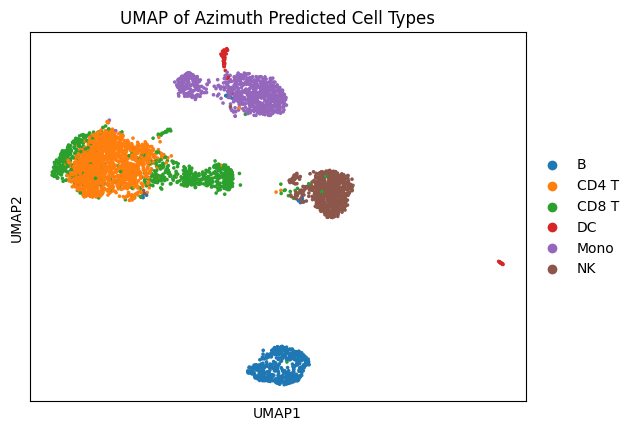

In [9]:
sc.tl.umap(adata)

sc.pl.umap(adata, color='predicted.celltype.l1', title='UMAP of Azimuth Predicted Cell Types')
#sc.pl.umap(adata, color='n_genes_by_counts', size=[5], cmap='Blues')

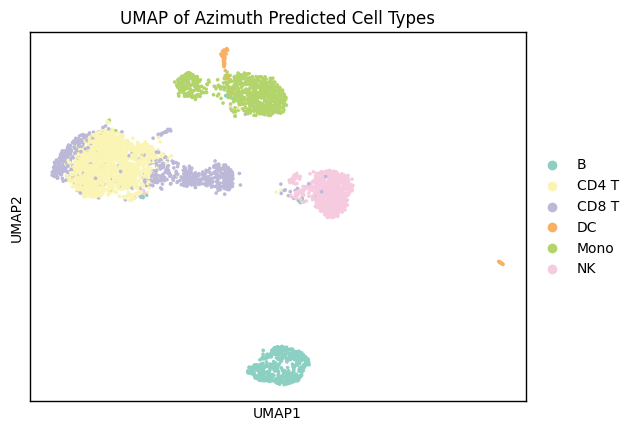

In [10]:
# inject your custom palette
adata.uns['predicted.celltype.l1_colors'] = [
    "#8CD0C3", "#FAF5B5", "#BCB9D8",
    "#F9B063", "#B3D46B", "#F7CBDF"
][:adata.obs['predicted.celltype.l1'].nunique()]

# plot without showing, and get back the Figure
fig = sc.pl.umap(
    adata,
    color='predicted.celltype.l1',
    title='UMAP of Azimuth Predicted Cell Types',
    legend_loc='right margin',
    frameon=True,
    show=False,
    return_fig=True
)

# the embedding lives in the first Axes
ax = fig.axes[0]

# make the spine (box) black
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)

plt.show()

# Calculating the SimRank similarity matrix

In [11]:
# Step 1: Extract the adjacency matrix from the AnnData object (sparse matrix format)
adjacency_matrix_knn = adata.obsp['connectivities']

# Step 2: Convert the sparse matrix to a dense matrix and move it to PyTorch tensor
adj_matrix_dense = adjacency_matrix_knn.toarray()  # Convert to dense (NumPy array)

# Step 3: Convert the dense matrix to a PyTorch tensor and move to GPU if necessary
#device = 'cuda' if torch.cuda.is_available() else 'cpu'
adj_matrix_tensor = torch.tensor(adj_matrix_dense, dtype=torch.float32).to(device)

# Step 4: Call the optimized SimRank function with the converted adjacency matrix
sim_matrix = simrank_similarity_optimized(adj_matrix_tensor, decay_factor=0.8, device=device)

# Step 5: Convert the result back to CPU if needed
sim_matrix_cpu = sim_matrix.cpu().numpy()


In [12]:
######################################################### this is the nearest neighbor connectivity matrix ###############################################
adj_matrix_dense.shape

(4403, 4403)

In [13]:
# symmetrize the np array "sim_matrix_cpu"
symmetrized_raw_sim_matrix = sim_matrix_cpu + sim_matrix_cpu.transpose()

# Convert the transposed array to a Pandas DataFrame
sim_matrix_raw_df = pd.DataFrame(symmetrized_raw_sim_matrix)

# Now df_sim_matrix contains the transposed data in a DataFrame format

# Normalize the similarity matrix
sim_matrix_raw_df_norm = sim_matrix_raw_df.div(sim_matrix_raw_df.sum(axis=1), axis=0)
#print(sim_matrix_raw_df_norm.head())




In [14]:
k=30
symmetrized_raw_sim_matrix_visualize = np.zeros_like(symmetrized_raw_sim_matrix)
for i in range(symmetrized_raw_sim_matrix.shape[0]):
  row = symmetrized_raw_sim_matrix[i, :]
  sorted_indices = np.argsort(row)[::-1]  # Sort in descending order
  top_k_indices = sorted_indices[:k]
  symmetrized_raw_sim_matrix_visualize[i, top_k_indices] = row[top_k_indices]



# Gaussian-kernel-transform and normalize the similarity matrix for random walk

In [15]:


# Extract the sparse distance matrix from AnnData and SimRank similarity matrix
distances_knn = adata.obsp['distances']  # kNN distance matrix
sim_matrix_cpu = sim_matrix_cpu + sim_matrix_cpu.transpose()  # SimRank similarity matrix from the previous step

# Set k (number of most similar cells to consider)
k = 30

# Call the function to compute Gaussian kernel-based weights with SimRank intersection
weights_matrix = gaussian_kernel_weights_with_simrank(distances_knn, sim_matrix_cpu, k, device=device)

weights_matrix_cpu = weights_matrix.cpu().numpy()


In [16]:
##################################################### this matrix indicates neighborhood structure after simrank  ##############################################
weights_matrix_cpu.shape

(4403, 4403)

In [17]:
# Convert both matrices to PyTorch tensors
weights_tensor = torch.tensor(weights_matrix_cpu, dtype=torch.float32)
simrank_tensor = torch.tensor(sim_matrix_cpu, dtype=torch.float32)

# Move tensors to GPU if available
weights_tensor = weights_tensor.to(device)
simrank_tensor = simrank_tensor.to(device)

# Perform element-wise multiplication using PyTorch
final_weight_tensor = weights_tensor * simrank_tensor

sim_matrix_df = pd.DataFrame(final_weight_tensor.cpu().numpy())


# Normalize the similarity matrix
sim_matrix_df_norm = sim_matrix_df.div(sim_matrix_df.sum(axis=1), axis=0)
sim_matrix_df_norm = sim_matrix_df_norm.fillna(0)
#print(sim_matrix_df_norm.head())



# Random walk with restart and calculate the imputed gene matrix

In [18]:
new_matrix, P_final = rwr_impute(sim_matrix_df_norm, adata_transcript_raw, alpha=0.3, max_iter=100, tol=1e-5, device=device)

Random walk with restart converged in 24 iterations.


In [19]:
# use the numpy array new_matrix to replace the gene expression data in the scanpy object "adata_transcript_new", and do the same analysis

adata_transcript_new = adata_transcript_raw.copy()
adata_transcript_new.X = new_matrix

# Perform the same analysis as before with adata_transcript_new
sc.pp.normalize_total(adata_transcript_new, target_sum=1e4)
sc.pp.log1p(adata_transcript_new)
sc.pp.highly_variable_genes(adata_transcript_new)
adata_new = adata_transcript_new
adata_new = adata_new[:, adata_new.var.highly_variable]
sc.pp.regress_out(adata_new, ["total_counts", "pct_counts_mt"])
sc.pp.neighbors(adata_new, n_neighbors=30, n_pcs=40)
sc.tl.umap(adata_new)



/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.12/dist-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 9070 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


# Visualization

## Visualize SimRank output

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

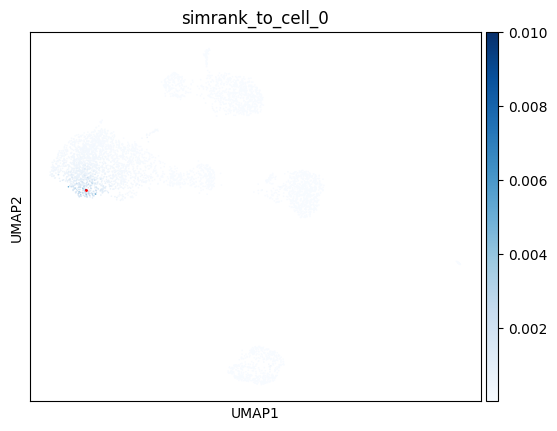

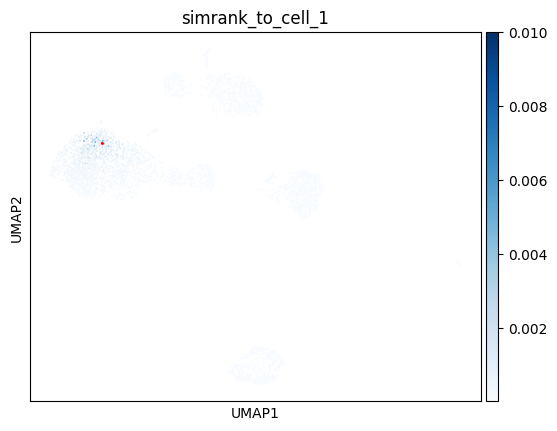

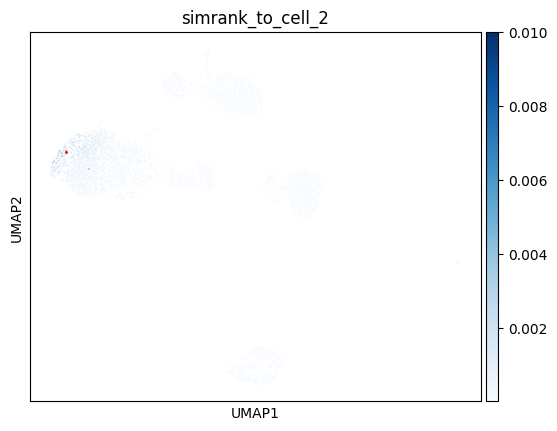

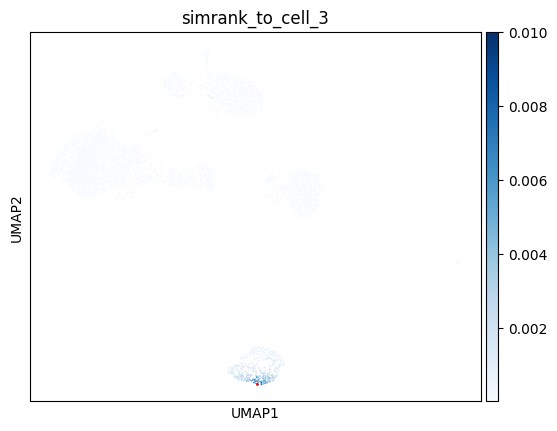

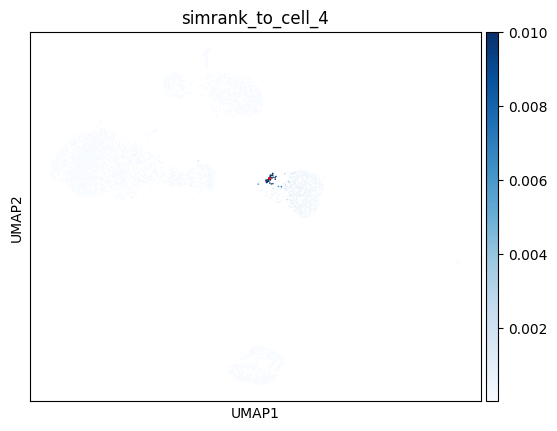

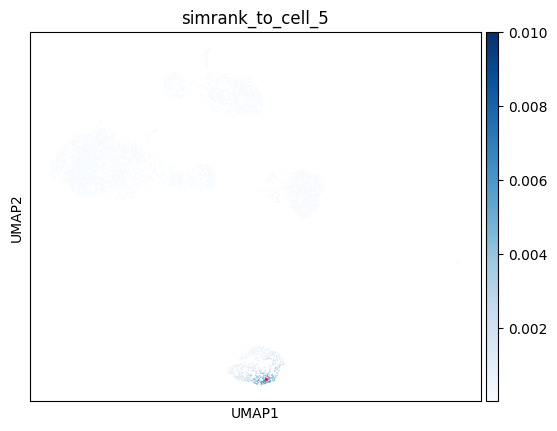

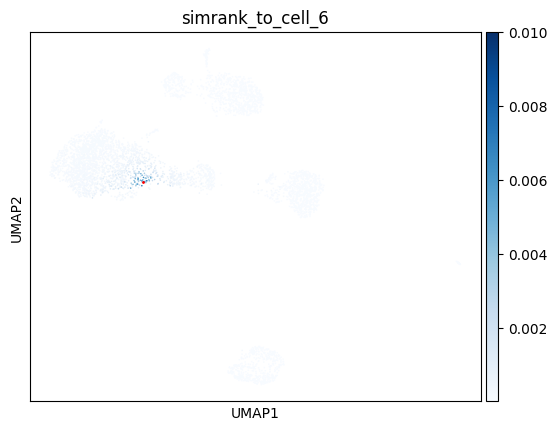

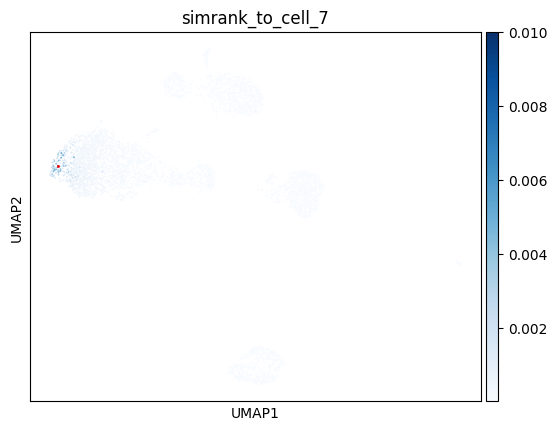

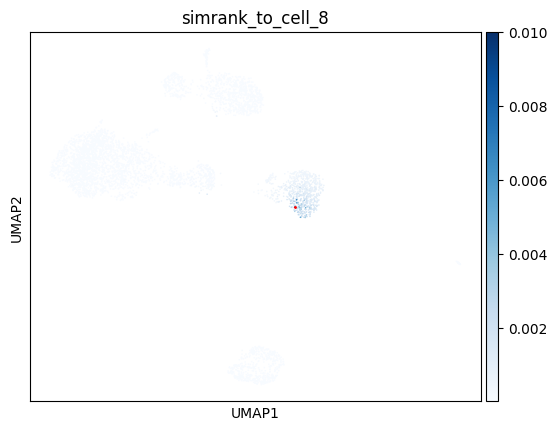

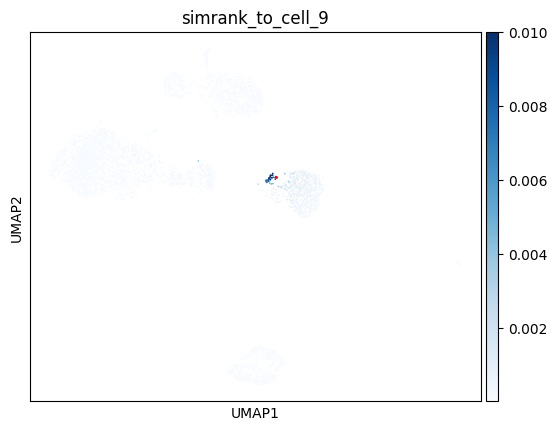

In [20]:
# Add SimRank scores to adata.obs
for i in range(10):  # Assuming you want to add scores for the first 10 cells
  adata.obs[f'simrank_to_cell_{i}'] = sim_matrix_raw_df_norm.iloc[i, :].values

for i in range(10):
    # Generate the UMAP plot without displaying it
    sc.pl.umap(adata, color=[f'simrank_to_cell_{i}'], size=[5], vmax=0.01, cmap='Blues', show=False)

    # Highlight the 10th cell (index 9)
    x = adata.obsm['X_umap'][i, 0]
    y = adata.obsm['X_umap'][i, 1]

    # Overlay the 10th cell in red
    plt.scatter(x, y, color='red', s=1)

    # Save the plot to a PNG file, name each file based on the loop index
    #plt.savefig(f'./similarity_plots/20nn/simrank_umap_cell_{i}.png', dpi=300, bbox_inches='tight')

    # Clear the current figure before the next iteration
    plt.clf()

# Plot UMAP with SimRank scores
for i in range(10):
  sc.pl.umap(adata, color=[f'simrank_to_cell_{i}'], size=[5], vmax=0.01, cmap='Blues', show = False)

  # Highlight the 10th cell (index 9)
  x = adata.obsm['X_umap'][i, 0]
  y = adata.obsm['X_umap'][i, 1]

  # Overlay the 10th cell in red
  plt.scatter(x, y, color='red', s=1)

  # Show the plot with the overlay
  plt.show()

## Visualize the transition matrix for Markov

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

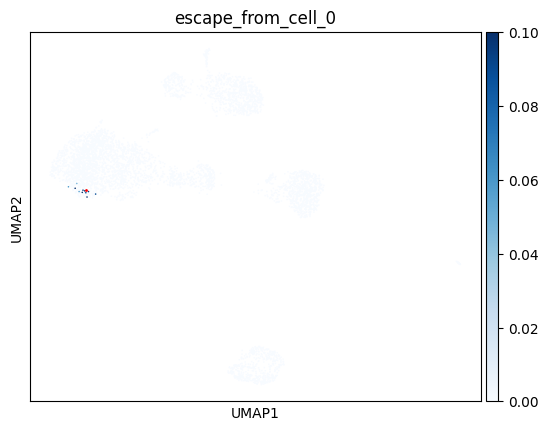

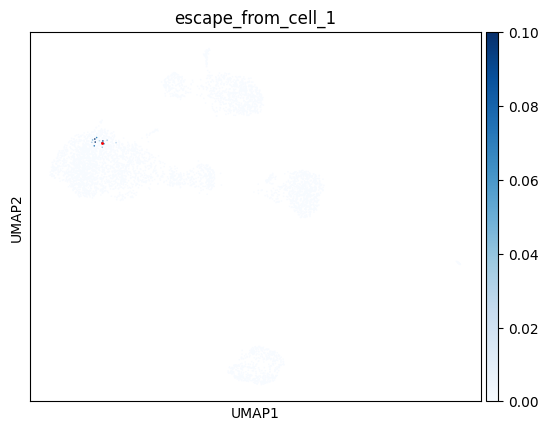

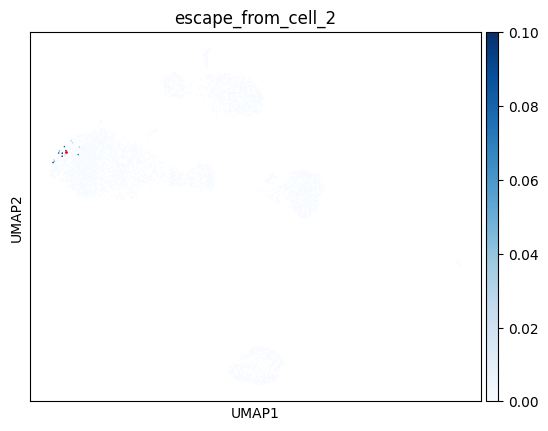

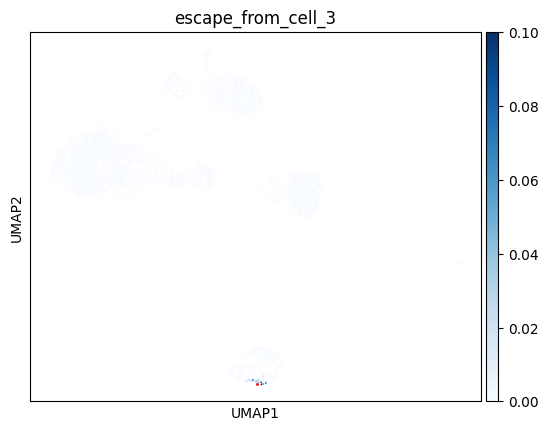

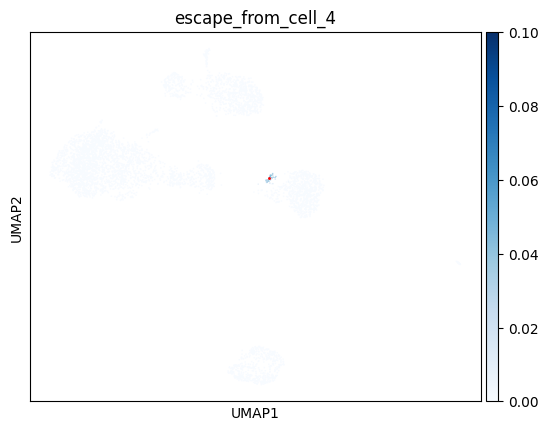

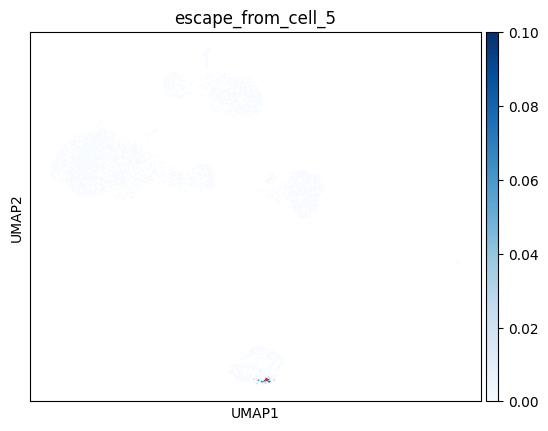

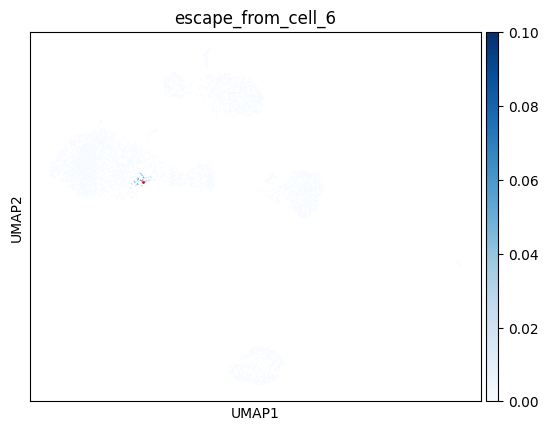

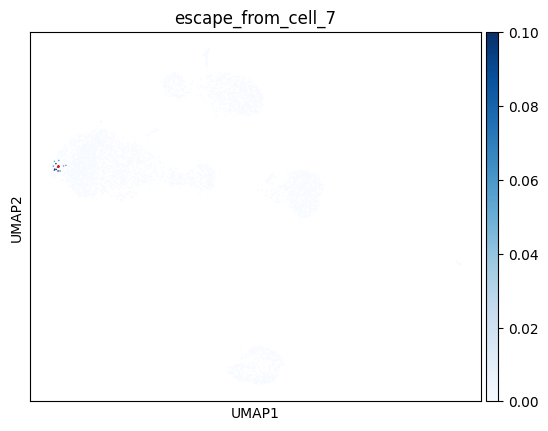

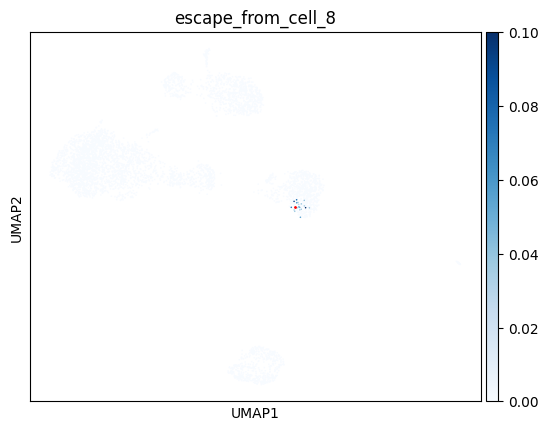

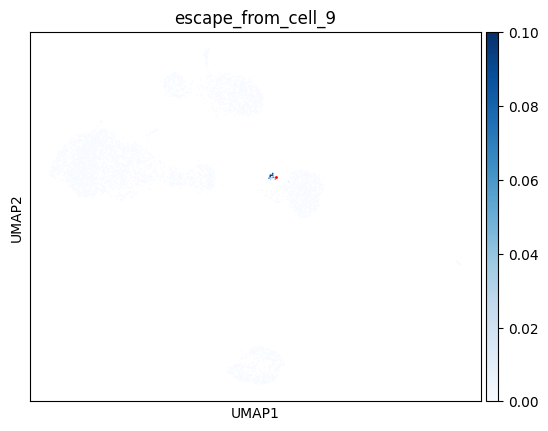

In [21]:
# Add SimRank scores to adata.obs
for i in range(10):
  adata.obs[f'escape_from_cell_{i}'] = sim_matrix_df_norm.iloc[i, :].values

for i in range(10):
    # Generate the UMAP plot without displaying it
    sc.pl.umap(adata, color=[f'escape_from_cell_{i}'], size=[5], vmax=0.1, cmap='Blues', show=False)

    # Highlight the 10th cell (index 9)
    x = adata.obsm['X_umap'][i, 0]
    y = adata.obsm['X_umap'][i, 1]

    # Overlay the 10th cell in red
    plt.scatter(x, y, color='red', s=1)

    #plt.savefig(f'./similarity_plots/20nn/simrank_umap_cell_{i}.png', dpi=300, bbox_inches='tight')

    # Clear the current figure before the next iteration
    plt.clf()

# Plot UMAP with SimRank scores
for i in range(10):
  sc.pl.umap(adata, color=[f'escape_from_cell_{i}'], size=[5], vmax=0.1, cmap='Blues', show = False)

  # Highlight the 10th cell (index 9)
  x = adata.obsm['X_umap'][i, 0]
  y = adata.obsm['X_umap'][i, 1]

  # Overlay the 10th cell in red
  plt.scatter(x, y, color='red', s=1)

  # Show the plot with the overlay
  plt.show()

In [22]:
P= P_final
P = pd.DataFrame(P)
# Add SimRank scores to adata.obs
for i in range(10):
  adata.obs[f'P{i}'] = P.iloc[i, :].values


In [23]:
# adata contains the UMAP coordinates and gene names are from adata_transcript_raw
matrix_1 = np.log1p(new_matrix)
# Extract the normalized gene expression matrix as a NumPy array
normalized_matrix = adata_transcript_raw.X.toarray() if hasattr(adata_transcript_raw.X, "toarray") else np.array(adata_transcript_raw.X)
matrix_2 = np.log1p(normalized_matrix)


# Extract UMAP coordinates from the existing AnnData object (adata)
umap_coords = adata.obsm['X_umap']

# Extract the first 10 gene names from adata_transcript_raw
gene_names = adata_transcript_raw.var_names[:10]

# Extract the first 10 genes from both matrices
matrix_1_first_10_genes = matrix_1[:, :10]
matrix_2_first_10_genes = matrix_2[:, :10]



## Visualize the difference between KNN and SCORED NN

In [24]:
def plot_neighbors(specific_cd8_index, adjacency_matrix, title, ax):
    # Get UMAP coordinates
    umap_coords = adata.obsm['X_umap']  # Ensure your UMAP coordinates are stored here

    # Initialize a color array for all cells
    colors = np.full(adata.shape[0], 'lightgray', dtype=object)  # Use 'lightgray' for other cells

    # Color the specific CD8 T cell in black
    colors[specific_cd8_index] = 'black'

    # Get neighbors from the specified adjacency matrix
    neighbors_indices = np.nonzero(adjacency_matrix[specific_cd8_index, :])[0]

    # Identify CD4 T cell neighbors
    cd4_neighbors = np.intersect1d(neighbors_indices, cd4_indices)
    # Color CD4 T neighbors in orange
    colors[cd4_neighbors] = '#E69F00'  # Orange color

    # Identify CD8 T cell neighbors
    cd8_neighbors = np.intersect1d(neighbors_indices, cd8_indices)
    cd8_neighbors = cd8_neighbors[cd8_neighbors != specific_cd8_index]  # Exclude the specific cell
    # Color CD8 T neighbors in sky blue
    colors[cd8_neighbors] = '#56B4E9'  # Sky blue color

    # Convert colors array to a list
    colors_list = colors.tolist()

    # Plot on the provided axes
    ax.scatter(umap_coords[:, 0], umap_coords[:, 1], c=colors_list, s=1, alpha=0.7)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_title(title)

    # Add a legend
    legend_patches = [
        mpatches.Patch(color='black', label='Given CD8 T cell'),
        mpatches.Patch(color='#E69F00', label='Non CD8 T neighbors'),
        mpatches.Patch(color='#56B4E9', label='CD8 T neighbors'),
        mpatches.Patch(color='lightgray', label='Other cells'),
    ]
    ax.legend(handles=legend_patches, loc='best')

In [25]:

# Get the indices of CD8 T cells and CD4 T cells
cd8_indices = np.where(adata.obs['predicted.celltype.l1'] == 'CD8 T')[0]
cd4_indices = np.where(adata.obs['predicted.celltype.l1'] != 'CD8 T')[0]
cd4_indices_set = set(cd4_indices)  # Convert to set for faster lookup

# Initialize a list to store the desired CD8 T cell indices
desired_cd8_indices = []

# Initialize lists to store CD4 T cell proportions
adj_cd4_proportions = []
weights_cd4_proportions = []
weights_cd4_proportions_filtered = []

# Iterate over each CD8 T cell
for i in cd8_indices:
    # Get neighbors from adj_matrix_dense
    adj_neighbors = np.nonzero(adj_matrix_dense[i, :])[0]
    # Get neighbors from symmetrized_raw_sim_matrix_visualize
    weights_neighbors = np.nonzero(symmetrized_raw_sim_matrix_visualize[i, :])[0]
    weights_neighbors_filtered = np.nonzero(weights_matrix_cpu[i, :])[0]

    # Compute CD4 T cell proportion in adj_neighbors
    adj_cd4_count = len(np.intersect1d(adj_neighbors, cd4_indices))
    adj_total_neighbors = len(adj_neighbors)
    adj_cd4_proportion = adj_cd4_count / adj_total_neighbors if adj_total_neighbors > 0 else 0
    adj_cd4_proportions.append(adj_cd4_proportion)

    # Compute CD4 T cell proportion in weights_neighbors
    weights_cd4_count = len(np.intersect1d(weights_neighbors, cd4_indices))
    weights_cd4_count_filtered = len(np.intersect1d(weights_neighbors_filtered, cd4_indices))
    weights_total_neighbors = len(weights_neighbors)
    weights_cd4_proportion = weights_cd4_count / weights_total_neighbors if weights_total_neighbors > 0 else 0
    weights_cd4_proportion_filtered = weights_cd4_count_filtered / weights_total_neighbors if weights_total_neighbors > 0 else 0
    weights_cd4_proportions.append(weights_cd4_proportion)
    weights_cd4_proportions_filtered.append(weights_cd4_proportion_filtered)

    # If adj_neighbors have a higher proportion of CD4 T cells than weights_neighbors
    if adj_cd4_proportion > weights_cd4_proportion:
        desired_cd8_indices.append(i)



In [26]:
#np.save("./10x/umap_coords.npy", adata.obsm['X_umap'])

In [27]:
cell_name = "AAACGAATCTCGCCTA-1"
idx = adata.obs_names.get_loc(cell_name)
print(idx)

6


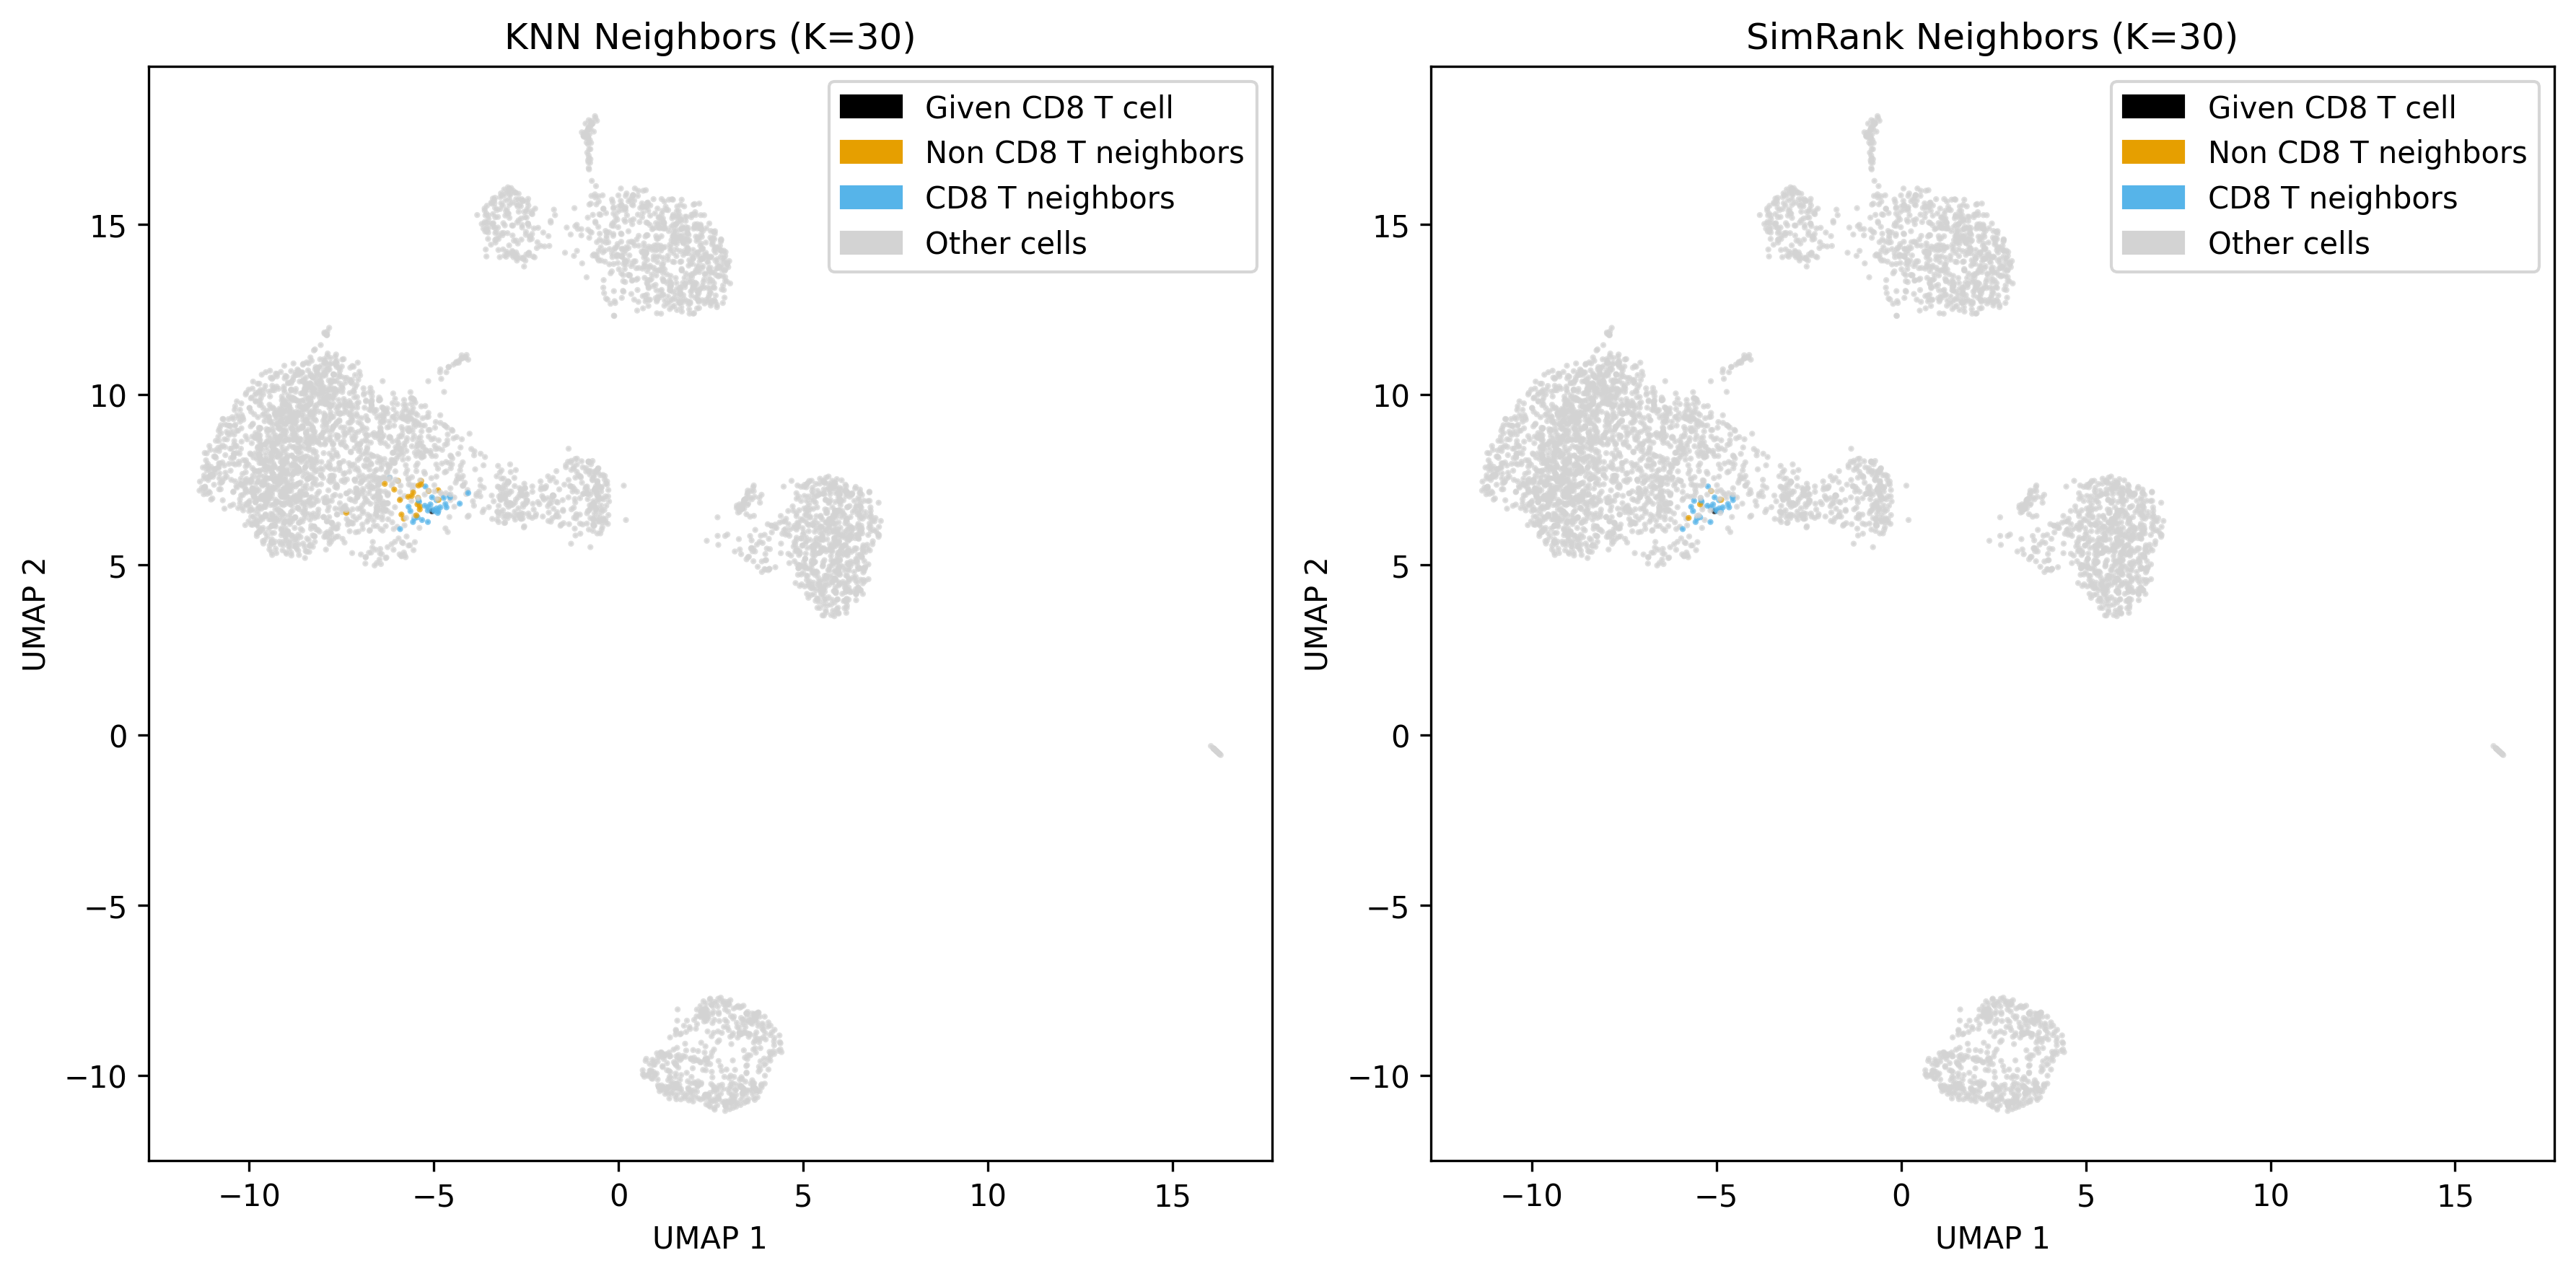

In [28]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), dpi=300)

axes = [axes]

  # Plot using adj_matrix_dense
plot_neighbors(
        6,
        adj_matrix_dense,
        f'KNN Neighbors (K=30)',
        axes[0][0])

    # Plot using symmetrized_raw_sim_matrix_visualize
plot_neighbors(
        6,
        symmetrized_raw_sim_matrix_visualize,
        f'SimRank Neighbors (K=30)',
        axes[0][1]
    )

# Adjust layout
plt.tight_layout()
plt.show()


Comparison of the distiribution of CD4 T proportions in CD8 T neighbors

/tmp/ipython-input-3453202608.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


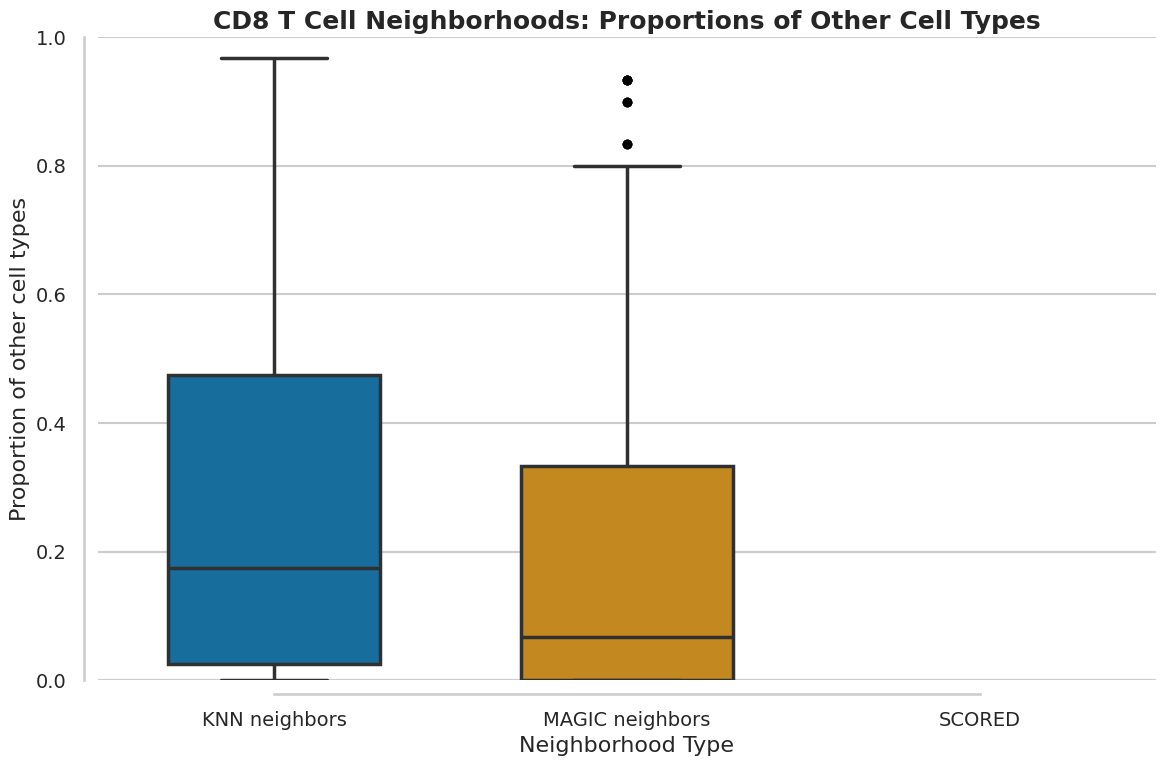

In [29]:
# Convert the proportions lists to arrays for easier manipulation
adj_cd4_proportions = np.array(adj_cd4_proportions)
weights_cd4_proportions = np.array(weights_cd4_proportions)
weights_cd4_proportions_filtered = np.array(weights_cd4_proportions_filtered)

# Create a DataFrame for easier plotting
data = pd.DataFrame({
    'CD8_T_cell_index': cd8_indices,
    'KNN neighbors': adj_cd4_proportions,
    'Proposed': weights_cd4_proportions_filtered
})

# Melt the DataFrame for seaborn plotting
data_melted = data.melt(id_vars='CD8_T_cell_index', value_vars=['KNN neighbors', 'Proposed'], var_name='Neighborhood_Type', value_name='CD4_T_Cell_Proportion')
data_melted_magic = pd.read_csv('./magic_output/10x/cd4_proportions_k_30.csv')
data_melted = pd.concat([data_melted, data_melted_magic], ignore_index=True)

# Save current style and context
original_style = sns.axes_style()
original_context = sns.plotting_context()

# Set the style and context for seaborn plots
sns.set_style('whitegrid')
sns.set_context('talk')

plt.figure(figsize=(12, 8))

# Create the boxplot with enhanced styling
ax = sns.boxplot(
    x='Neighborhood_Type',
    y='CD4_T_Cell_Proportion',
    data=data_melted,
    palette='colorblind',
    width=0.6,
    linewidth=2.5,
    fliersize=6,      # Size of the outlier markers
    flierprops={
        'marker': 'o',
        'markerfacecolor': 'black',
        'markeredgecolor': 'black',
        'markersize': 6,
        'linestyle': 'none',
    },
    order=["KNN neighbors", "MAGIC neighbors", "SCORED"]
)

# Customize the plot
ax.set_title('CD8 T Cell Neighborhoods: Proportions of Other Cell Types', fontsize=18, fontweight='bold')
ax.set_xlabel('Neighborhood Type', fontsize=16)
ax.set_ylabel('Proportion of other cell types', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)

# Remove the top and right spines
sns.despine(offset=10, trim=True)

plt.ylim(bottom=0, top=1)

plt.tight_layout()
plt.show()


# Reset to original style and context
sns.set_style(original_style)
sns.set_context(original_context)

# varying k

In [30]:
# Define the range of k values
k_values = list(range(5, 51, 5))

# These lists will hold the entire distribution (not just mean) for each k
# for CD4+ T cell proportions in neighborhoods of CD8+ T cells:
all_cd4_in_cd8_data = []  # will be turned into a DataFrame later

# Similarly, for CD8+ T cell proportions in neighborhoods of CD4+ T cells:
all_cd8_in_cd4_data = []


# Initialize lists to store the results
knn_cd4 = []
simrank_cd4 = []
simrank_filtered_cd4 = []
knn_cd8 = []
simrank_cd8 = []
simrank_filtered_cd8 = []


for k in k_values:

  pbmc = sc.read_h5ad('./10x/transcript_raw.h5ad')
  # pbmc.var = pbmc.var.reset_index(names='transcript_ids').set_index('transcript_names')
  azimuth_pred = pd.read_csv('./10x/azimuth_pred.tsv', sep='\t', index_col=0)
  cell_idx = azimuth_pred.index.intersection(pbmc.obs.index)

  pbmc = pbmc[cell_idx]
  pbmc.obs = azimuth_pred.loc[pbmc.obs.index]

  pbmc = pbmc[pbmc.obs['predicted.celltype.l1'].isin(
      ['CD4 T', 'CD8 T', 'B', 'NK', 'Mono', 'DC']
  )]
  pbmc.obs['cell_type'] = pbmc.obs['predicted.celltype.l1'].values
  pbmc.obs['cell_type'] = pbmc.obs['cell_type'].replace({'CD4 T': 'CD4+T cells'})
  pbmc.obs['cell_type'] = pbmc.obs['cell_type'].replace({'CD8 T': 'CD8+T cells'})


  sc.pp.filter_genes(pbmc, min_cells=3)


  # annotate the group of mitochondrial genes as "mt"
  pbmc.var["mt"] = pbmc.var_names.str.startswith("MT-")
  sc.pp.calculate_qc_metrics(
      pbmc, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
  )

  sc.pp.normalize_total(pbmc, target_sum=1e4)
  pbmc_raw = pbmc.copy()

  sc.pp.log1p(pbmc)

  sc.pp.highly_variable_genes(pbmc)

  pbmc = pbmc[:, pbmc.var.highly_variable]
  sc.pp.regress_out(pbmc, ["total_counts", "pct_counts_mt"])

  sc.pp.neighbors(pbmc, n_neighbors=k, n_pcs=40)

  sc.tl.umap(pbmc)


  #sc.pl.umap(pbmc, color='cell_type', title='UMAP of ADT Cell Types')

  # Step 1: Extract the adjacency matrix from the AnnData object (sparse matrix format)
  adjacency_matrix_knn = pbmc.obsp['connectivities']  # Assuming the kNN graph is stored here (sparse matrix)

  # Step 2: Convert the sparse matrix to a dense matrix and move it to PyTorch tensor
  adj_matrix_dense = adjacency_matrix_knn.toarray()  # Convert to dense (NumPy array)

  # Step 3: Convert the dense matrix to a PyTorch tensor and move to GPU
  adj_matrix_tensor = torch.tensor(adj_matrix_dense, dtype=torch.float32).to(device)

  # Step 4: Call the optimized SimRank function with the converted adjacency matrix
  sim_matrix = simrank_similarity_optimized(adj_matrix_tensor, decay_factor=0.8, device=device)

  # Step 5: Convert the result back to CPU
  sim_matrix_cpu = sim_matrix.cpu().numpy()

  # symmetrize the np array "sim_matrix_cpu"
  symmetrized_raw_sim_matrix = sim_matrix_cpu + sim_matrix_cpu.transpose()

  # Convert the transposed array to a Pandas DataFrame
  sim_matrix_raw_df = pd.DataFrame(symmetrized_raw_sim_matrix)


  # Normalize the similarity matrix
  sim_matrix_raw_df_norm = sim_matrix_raw_df.div(sim_matrix_raw_df.sum(axis=1), axis=0)
  #print(sim_matrix_raw_df_norm.head())

  symmetrized_raw_sim_matrix_visualize = np.zeros_like(symmetrized_raw_sim_matrix)
  for i in range(symmetrized_raw_sim_matrix.shape[0]):
    row = symmetrized_raw_sim_matrix[i, :]
    sorted_indices = np.argsort(row)[::-1]  # Sort in descending order
    top_k_indices = sorted_indices[:k]
    symmetrized_raw_sim_matrix_visualize[i, top_k_indices] = row[top_k_indices]

    # Extract the sparse distance matrix from AnnData and SimRank similarity matrix
  distances_knn = pbmc.obsp['distances']  # kNN distance matrix
  sim_matrix_cpu = sim_matrix_cpu + sim_matrix_cpu.transpose()


  # Call the function to compute Gaussian kernel-based weights with SimRank intersection
  weights_matrix = gaussian_kernel_weights_with_simrank(distances_knn, sim_matrix_cpu, k, device=device)

  weights_matrix_cpu = weights_matrix.cpu().numpy()

  # Convert both matrices to PyTorch tensors
  weights_tensor = torch.tensor(weights_matrix_cpu, dtype=torch.float32)
  simrank_tensor = torch.tensor(sim_matrix_cpu, dtype=torch.float32)

  weights_tensor = weights_tensor.to(device)
  simrank_tensor = simrank_tensor.to(device)

  # Perform element-wise multiplication using PyTorch
  final_weight_tensor = weights_tensor * simrank_tensor

  sim_matrix_df = pd.DataFrame(final_weight_tensor.cpu().numpy())


  # Normalize the similarity matrix
  sim_matrix_df_norm = sim_matrix_df.div(sim_matrix_df.sum(axis=1), axis=0)
  #print(sim_matrix_df_norm.head())


  # Get the indices of CD8 T cells and CD4 T cells
  cd8_indices = np.where(pbmc.obs['cell_type'] == 'CD8+T cells')[0]
  cd4_indices = np.where(pbmc.obs['cell_type'] != 'CD8+T cells')[0]
  cd4_indices_set = set(cd4_indices)  # Convert to set for faster lookup

  # Initialize a list to store the desired CD8 T cell indices
  desired_cd8_indices = []

  # Initialize lists to store CD4 T cell proportions
  adj_cd4_proportions = []
  weights_cd4_proportions = []
  weights_cd4_proportions_filtered = []

  # Iterate over each CD8 T cell
  for i in cd8_indices:
      # Get neighbors from adj_matrix_dense
      adj_neighbors = np.nonzero(adj_matrix_dense[i, :])[0]
      # Get neighbors from symmetrized_raw_sim_matrix_visualize
      weights_neighbors = np.nonzero(symmetrized_raw_sim_matrix_visualize[i, :])[0]
      weights_neighbors_filtered = np.nonzero(weights_matrix_cpu[i, :])[0]

      # Compute CD4 T cell proportion in adj_neighbors
      adj_cd4_count = len(np.intersect1d(adj_neighbors, cd4_indices))
      adj_total_neighbors = len(adj_neighbors)
      adj_cd4_proportion = adj_cd4_count / adj_total_neighbors if adj_total_neighbors > 0 else 0
      adj_cd4_proportions.append(adj_cd4_proportion)

      # Compute CD4 T cell proportion in weights_neighbors
      weights_cd4_count = len(np.intersect1d(weights_neighbors, cd4_indices))
      weights_cd4_count_filtered = len(np.intersect1d(weights_neighbors_filtered, cd4_indices))
      weights_total_neighbors = len(weights_neighbors)
      weights_cd4_proportion = weights_cd4_count / weights_total_neighbors if weights_total_neighbors > 0 else 0
      weights_cd4_proportion_filtered = weights_cd4_count_filtered / weights_total_neighbors if weights_total_neighbors > 0 else 0
      weights_cd4_proportions.append(weights_cd4_proportion)
      weights_cd4_proportions_filtered.append(weights_cd4_proportion_filtered)

      # If adj_neighbors have a higher proportion of CD4 T cells than weights_neighbors
      if adj_cd4_proportion > weights_cd4_proportion:
          desired_cd8_indices.append(i)
  # Store all the data points (instead of just mean)
  for val in adj_cd4_proportions:
      all_cd4_in_cd8_data.append({'k': k, 'method': 'KNN', 'proportion': val})
  #for val in weights_cd4_proportions:
      #all_cd4_in_cd8_data.append({'k': k, 'method': 'SimRank', 'proportion': val})
  for val in weights_cd4_proportions_filtered:
      all_cd4_in_cd8_data.append({'k': k, 'method': 'Proposed', 'proportion': val})
  df_cd4_in_cd8 = pd.DataFrame(all_cd4_in_cd8_data)  # Data for: CD4 T cell proportion in neighborhoods of CD8 T

  # Convert the proportions lists to arrays for easier manipulation
  adj_cd4_proportions = np.array(adj_cd4_proportions)
  weights_cd4_proportions = np.array(weights_cd4_proportions)
  weights_cd4_proportions_filtered = np.array(weights_cd4_proportions_filtered)



  # Get the indices of CD8 T cells and CD4 T cells
  cd4_indices = np.where(pbmc.obs['cell_type'] == 'CD4+T cells')[0]
  cd8_indices = np.where(pbmc.obs['cell_type'] != 'CD4+T cells')[0]
  cd4_indices_set = set(cd4_indices)  # Convert to set for faster lookup

  # Initialize a list to store the desired CD4 T cell indices
  desired_cd4_indices = []

  # Initialize lists to store CD4 T cell proportions
  adj_cd8_proportions = []
  weights_cd8_proportions = []
  weights_cd8_proportions_filtered = []

  # Iterate over each CD4 T cell
  for i in cd4_indices:
      # Get neighbors from adj_matrix_dense
      adj_neighbors = np.nonzero(adj_matrix_dense[i, :])[0]
      # Get neighbors from symmetrized_raw_sim_matrix_visualize
      weights_neighbors = np.nonzero(symmetrized_raw_sim_matrix_visualize[i, :])[0]
      weights_neighbors_filtered = np.nonzero(weights_matrix_cpu[i, :])[0]

      # Compute CD8 T cell proportion in adj_neighbors
      adj_cd8_count = len(np.intersect1d(adj_neighbors, cd8_indices))
      adj_total_neighbors = len(adj_neighbors)
      adj_cd8_proportion = adj_cd8_count / adj_total_neighbors if adj_total_neighbors > 0 else 0
      adj_cd8_proportions.append(adj_cd8_proportion)

      # Compute CD8 T cell proportion in weights_neighbors
      weights_cd8_count = len(np.intersect1d(weights_neighbors, cd8_indices))
      weights_cd8_count_filtered = len(np.intersect1d(weights_neighbors_filtered, cd8_indices))
      weights_total_neighbors = len(weights_neighbors)
      weights_cd8_proportion = weights_cd8_count / weights_total_neighbors if weights_total_neighbors > 0 else 0
      weights_cd8_proportion_filtered = weights_cd8_count_filtered / weights_total_neighbors if weights_total_neighbors > 0 else 0
      weights_cd8_proportions.append(weights_cd8_proportion)
      weights_cd8_proportions_filtered.append(weights_cd8_proportion_filtered)

      # If adj_neighbors have a higher proportion of CD4 T cells than weights_neighbors
      if adj_cd8_proportion > weights_cd8_proportion:
          desired_cd4_indices.append(i)

  for val in adj_cd8_proportions:
      all_cd8_in_cd4_data.append({'k': k, 'method': 'KNN', 'proportion': val})
  #for val in weights_cd8_proportions:
      #all_cd8_in_cd4_data.append({'k': k, 'method': 'SimRank', 'proportion': val})
  for val in weights_cd8_proportions_filtered:
      all_cd8_in_cd4_data.append({'k': k, 'method': 'Proposed', 'proportion': val})
  df_cd8_in_cd4 = pd.DataFrame(all_cd8_in_cd4_data)  # Data for: CD8 T cell proportion in neighborhoods of CD4 T


  # Convert the proportions lists to arrays for easier manipulation
  adj_cd8_proportions = np.array(adj_cd8_proportions)
  weights_cd8_proportions = np.array(weights_cd8_proportions)
  weights_cd8_proportions_filtered = np.array(weights_cd8_proportions_filtered)



  # Calculate mean proportions for current k
  knn_cd4.append(np.mean(adj_cd4_proportions))
  simrank_cd4.append(np.mean(weights_cd4_proportions))
  simrank_filtered_cd4.append(np.mean(weights_cd4_proportions_filtered))
  knn_cd8.append(np.mean(adj_cd8_proportions))
  simrank_cd8.append(np.mean(weights_cd8_proportions))
  simrank_filtered_cd8.append(np.mean(weights_cd8_proportions_filtered))

/tmp/ipython-input-1669576165.py:34: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  pbmc.obs['cell_type'] = pbmc.obs['predicted.celltype.l1'].values
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1176: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.12/dist-packages/scanpy/neig

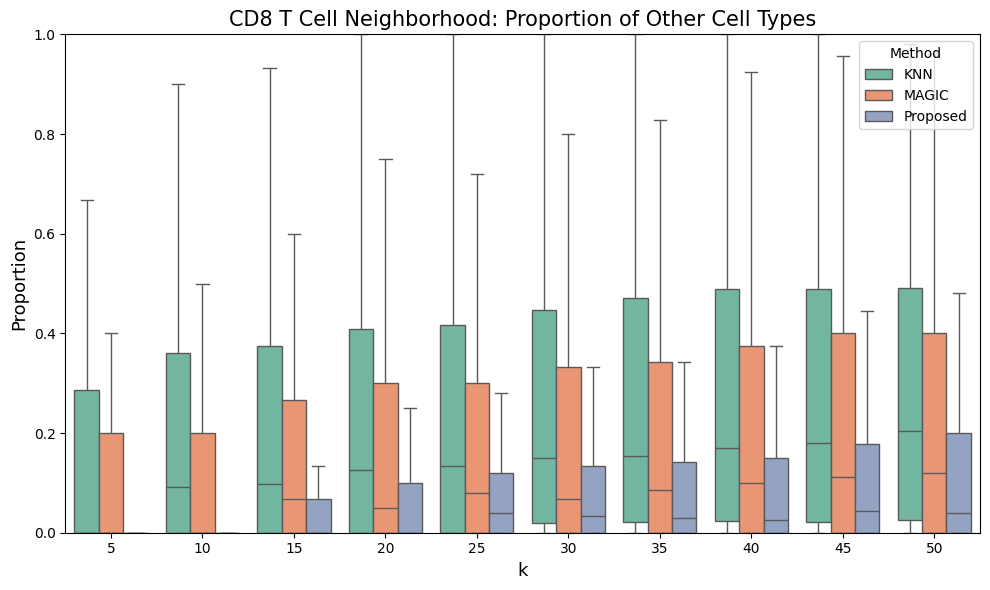

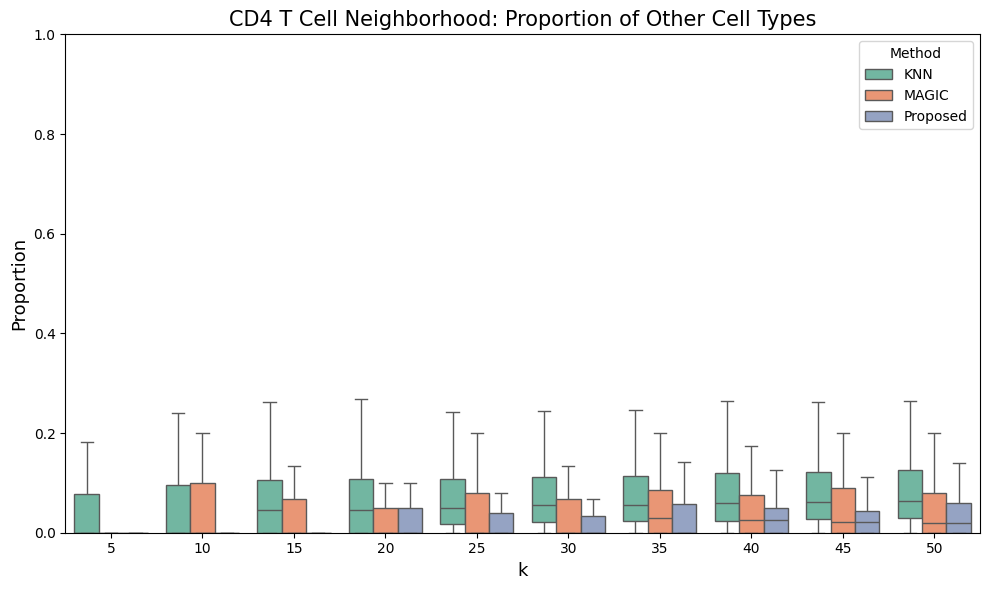

In [31]:
# A) Box plot for CD4 T cell proportion in neighborhoods of CD8 T cells

df_cd4_in_cd8_magic = pd.read_csv('./magic_output/10x/cd4_proportions_vary_k.csv')
df_cd4_in_cd8 = pd.concat([df_cd4_in_cd8, df_cd4_in_cd8_magic], ignore_index=True)


plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_cd4_in_cd8,
    x='k',            # group by the different k values
    y='proportion',
    hue='method',     # show KNN, SimRank, SimRank Filtered side by side
    palette='Set2',
    hue_order=["KNN", "MAGIC", "Proposed"],
    showfliers=False
)
plt.ylim(bottom=0, top = 1)
plt.title('CD8 T Cell Neighborhood: Proportion of Other Cell Types', fontsize=15)
plt.xlabel('k', fontsize=13)
plt.ylabel('Proportion', fontsize=13)
plt.legend(title='Method', loc='upper right')
plt.tight_layout()
plt.show()

# B) Box plot for CD8 T cell proportion in neighborhoods of CD4 T cells

df_cd8_in_cd4_magic = pd.read_csv('./magic_output/10x/cd8_proportions_vary_k.csv')
df_cd8_in_cd4 = pd.concat([df_cd8_in_cd4, df_cd8_in_cd4_magic], ignore_index=True)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_cd8_in_cd4,
    x='k',
    y='proportion',
    hue='method',
    palette='Set2',
    hue_order=["KNN", "MAGIC", "Proposed"],
    showfliers=False
)
plt.ylim(bottom=0, top = 1)
plt.title('CD4 T Cell Neighborhood: Proportion of Other Cell Types', fontsize=15)
plt.xlabel('k', fontsize=13)
plt.ylabel('Proportion', fontsize=13)
plt.legend(title='Method', loc='upper right')
plt.tight_layout()
plt.show()

/tmp/ipython-input-1027217855.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cd4_in_cd8_filt['method'] = df_cd4_in_cd8_filt['method'].replace('Proposed', 'SCORED')


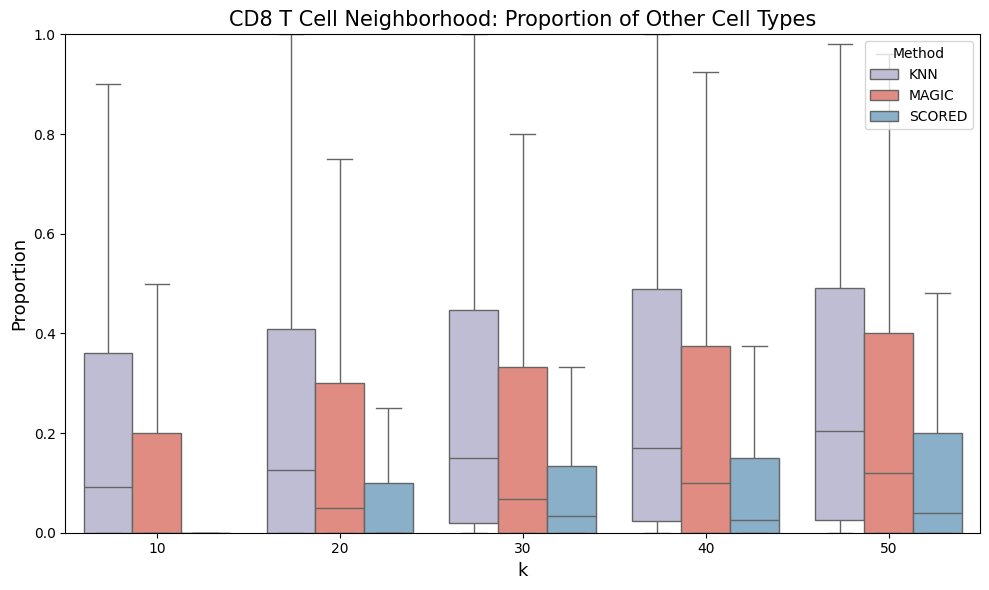

/tmp/ipython-input-1027217855.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cd8_in_cd4_filt['method'] = df_cd8_in_cd4_filt['method'].replace('Proposed', 'SCORED')


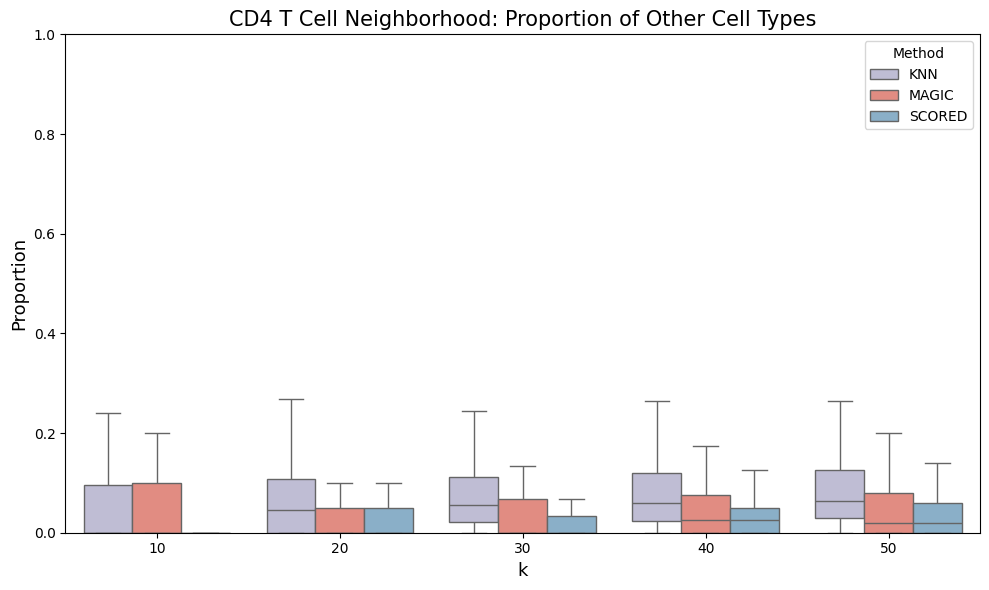

In [32]:
# paper figures

# 1) pick the ks to show
selected_ks = [10, 20, 30, 40, 50]

# 2) filter data
df_cd4_in_cd8_filt = df_cd4_in_cd8[df_cd4_in_cd8['k'].isin(selected_ks)]


df_cd4_in_cd8_filt['method'] = df_cd4_in_cd8_filt['method'].replace('Proposed', 'SCORED')

# 3) define hue‐order and colour mapping
hue_order = ["KNN", "MAGIC", "SCORED"]
palette = {
    "KNN":      "#BCB9D8",
    "MAGIC":    "#F18072",
    "SCORED": "#80B1D2"
}

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_cd4_in_cd8_filt,
    x='k',
    y='proportion',
    hue='method',
    order=selected_ks,
    hue_order=hue_order,  # ensures consistent method ordering
    palette=palette,
    showfliers=False
)
plt.ylim(0, 1)
plt.title('CD8 T Cell Neighborhood: Proportion of Other Cell Types', fontsize=15)
plt.xlabel('k', fontsize=13)
plt.ylabel('Proportion', fontsize=13)
plt.legend(title='Method', loc='upper right')
plt.tight_layout()
plt.show()

df_cd8_in_cd4_filt = df_cd8_in_cd4[df_cd8_in_cd4['k'].isin(selected_ks)]

df_cd8_in_cd4_filt['method'] = df_cd8_in_cd4_filt['method'].replace('Proposed', 'SCORED')

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_cd8_in_cd4_filt,
    x='k',
    y='proportion',
    hue='method',
    order=selected_ks,
    hue_order=hue_order,
    palette=palette,
    showfliers=False
)
plt.ylim(0, 1)
plt.title('CD4 T Cell Neighborhood: Proportion of Other Cell Types', fontsize=15)
plt.xlabel('k', fontsize=13)
plt.ylabel('Proportion', fontsize=13)
plt.legend(title='Method', loc='upper right')
plt.tight_layout()
plt.show()


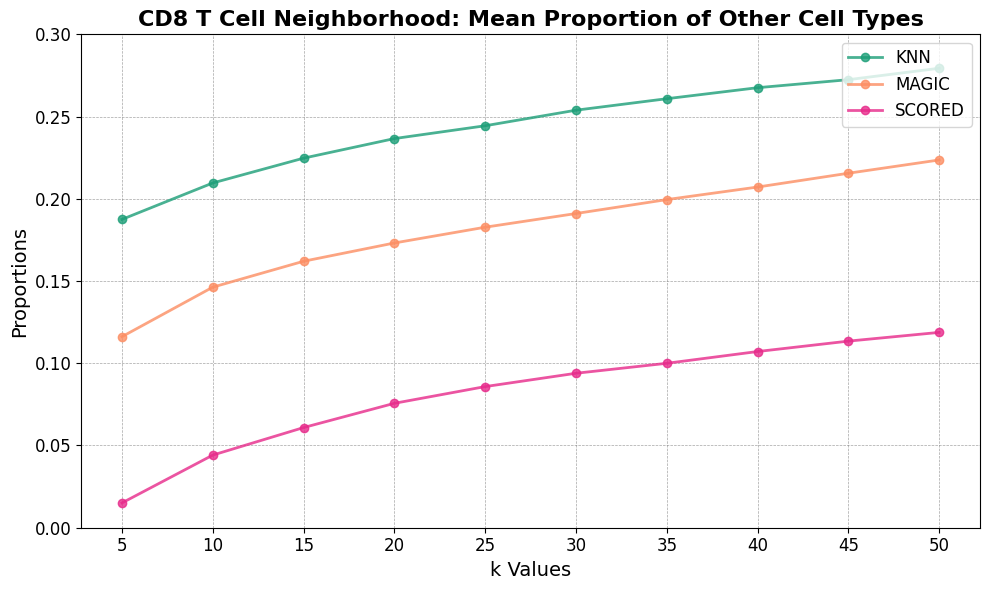

In [33]:
magic_cd4 = np.load('./magic_output/10x/magic_cd4.npy')
# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(k_values, knn_cd4, marker='o', linestyle='-', linewidth=2, color='#1b9e77', label='KNN', alpha=0.8)
plt.plot(k_values, magic_cd4, marker='o', linestyle='-', linewidth=2, color='#fc8d62', label='MAGIC', alpha=0.8)
plt.plot(k_values, simrank_filtered_cd4, marker='o', linestyle='-', linewidth=2, color='#e7298a', label='SCORED', alpha=0.8)


plt.title("CD8 T Cell Neighborhood: Mean Proportion of Other Cell Types", fontsize=16, weight='bold')
plt.xlabel("k Values", fontsize=14)
plt.ylabel("Proportions", fontsize=14)
plt.xticks(k_values, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.ylim(bottom=0, top=0.3)

# Show the plot
plt.show()

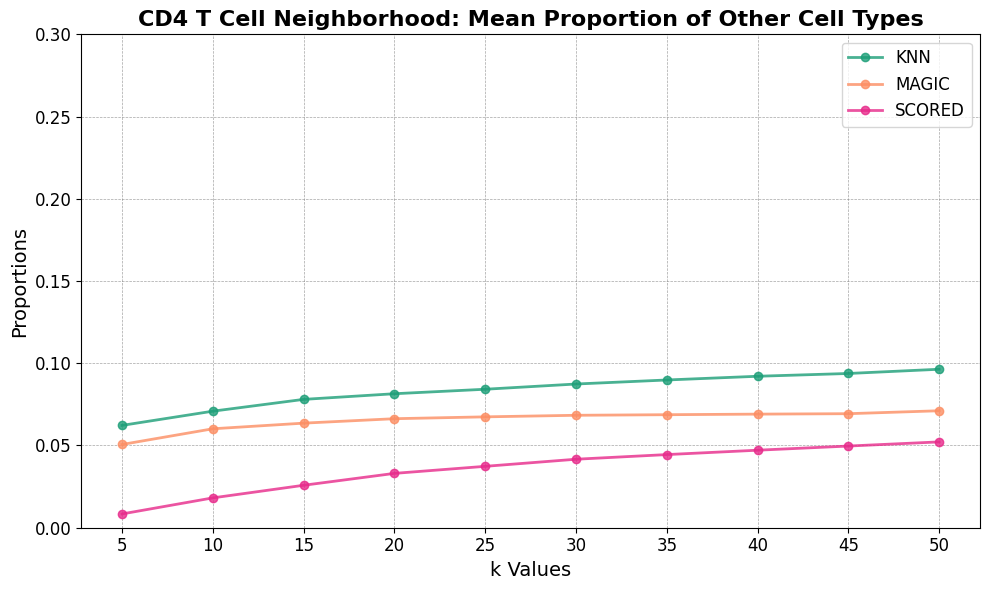

In [34]:
magic_cd8 = np.load('./magic_output/10x/magic_cd8.npy')

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(k_values, knn_cd8, marker='o', linestyle='-', linewidth=2, color='#1b9e77', label='KNN', alpha=0.8)
plt.plot(k_values, magic_cd8, marker='o', linestyle='-', linewidth=2, color='#fc8d62', label='MAGIC', alpha=0.8)
plt.plot(k_values, simrank_filtered_cd8, marker='o', linestyle='-', linewidth=2, color='#e7298a', label='SCORED', alpha=0.8)




plt.title("CD4 T Cell Neighborhood: Mean Proportion of Other Cell Types", fontsize=16, weight='bold')
plt.xlabel("k Values", fontsize=14)
plt.ylabel("Proportions", fontsize=14)
plt.xticks(k_values, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.ylim(bottom=0, top = 0.3)
# Show the plot
plt.show()